In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from preprocess import group_routes_by_flight_date


df = pd.read_csv("data/itineraries_filtered.csv")
df.head()

,legId,searchDate,flightDate,startingAirport,destinationAirport,fareBasisCode,elapsedDays,isBasicEconomy,isRefundable,isNonStop,baseFare,totalFare,seatsRemaining,totalTravelDistance,segmentsDepartureTimeEpochSeconds,segmentsArrivalTimeEpochSeconds,segmentsAirlineCode,segmentsEquipmentDescription,segmentsDurationInSeconds,segmentsCabinCode
0,fcdadfc373ea6d16b726f7ef7ca57659,2022-04-16,2022-04-25,ORD,LAX,M3AIZNN1,0,False,False,True,305.12,342.60,7,1745.0,1650925200,1650941220,AA,Boeing 737-800,16020,coach
1,987b7fe3932c993fcee494bad2178b3f,2022-04-16,2022-04-17,ORD,LGA,G0AHZNN1,0,False,False,True,141.40,166.61,7,720.0,1650213000,1650220500,AA,Boeing 737-800,7500,coach
2,1ee950ecc949b7abb8bfa107e8aa81c4,2022-04-16,2022-04-23,MIA,JFK,B0APZNN1,0,False,False,True,772.09,844.60,7,1104.0,1650724200,1650735720,AA,Boeing 737-800,11520,coach
3,55a9ed5ef26919db086a638657c6e802,2022-04-16,2022-04-24,EWR,MIA,PL7QUEL1,0,False,False,True,27.91,44.60,7,1104.0,1650846600,1650858420,B6,Airbus A320,11820,coach
4,69327c333f7c7e45c479085e9dc73d0d,2022-04-16,2022-04-22,ORD,LGA,B0AJZNN1,0,False,False,True,169.30,196.60,6,720.0,1650648600,1650656100,B6,Airbus A319,7500,coach


In [8]:
# Transform segmentsDepartureTimeEpochSeconds and segmentsArrivalTimeEpochSeconds to datetime
df["segmentsDepartureTime"] = pd.to_datetime(
    df["segmentsDepartureTimeEpochSeconds"], unit="s"
)
df["segmentsArrivalTime"] = pd.to_datetime(
    df["segmentsArrivalTimeEpochSeconds"], unit="s"
)

# Transform segmentsDurationSeconds to HH:MM:SS
df["segmentsDuration"] = pd.to_timedelta(df["segmentsDurationInSeconds"], unit="s")

df.head()

,legId,searchDate,flightDate,startingAirport,destinationAirport,fareBasisCode,elapsedDays,isBasicEconomy,isRefundable,isNonStop,...,totalTravelDistance,segmentsDepartureTimeEpochSeconds,segmentsArrivalTimeEpochSeconds,segmentsAirlineCode,segmentsEquipmentDescription,segmentsDurationInSeconds,segmentsCabinCode,segmentsDepartureTime,segmentsArrivalTime,segmentsDuration
0,fcdadfc373ea6d16b726f7ef7ca57659,2022-04-16,2022-04-25,ORD,LAX,M3AIZNN1,0,False,False,True,...,1745.0,1650925200,1650941220,AA,Boeing 737-800,16020,coach,2022-04-25 22:20:00,2022-04-26 02:47:00,0 days 04:27:00
1,987b7fe3932c993fcee494bad2178b3f,2022-04-16,2022-04-17,ORD,LGA,G0AHZNN1,0,False,False,True,...,720.0,1650213000,1650220500,AA,Boeing 737-800,7500,coach,2022-04-17 16:30:00,2022-04-17 18:35:00,0 days 02:05:00
2,1ee950ecc949b7abb8bfa107e8aa81c4,2022-04-16,2022-04-23,MIA,JFK,B0APZNN1,0,False,False,True,...,1104.0,1650724200,1650735720,AA,Boeing 737-800,11520,coach,2022-04-23 14:30:00,2022-04-23 17:42:00,0 days 03:12:00
3,55a9ed5ef26919db086a638657c6e802,2022-04-16,2022-04-24,EWR,MIA,PL7QUEL1,0,False,False,True,...,1104.0,1650846600,1650858420,B6,Airbus A320,11820,coach,2022-04-25 00:30:00,2022-04-25 03:47:00,0 days 03:17:00
4,69327c333f7c7e45c479085e9dc73d0d,2022-04-16,2022-04-22,ORD,LGA,B0AJZNN1,0,False,False,True,...,720.0,1650648600,1650656100,B6,Airbus A319,7500,coach,2022-04-22 17:30:00,2022-04-22 19:35:00,0 days 02:05:00


Total number of unique routes and dates: 38121
Average number of search dates per route-date: 5.30
Median number of search dates per route-date: 4.00
Min number of search dates per route-date: 1
Max number of search dates per route-date: 34

Most frequently observed route-date: LGA → ORD on 2022-08-25


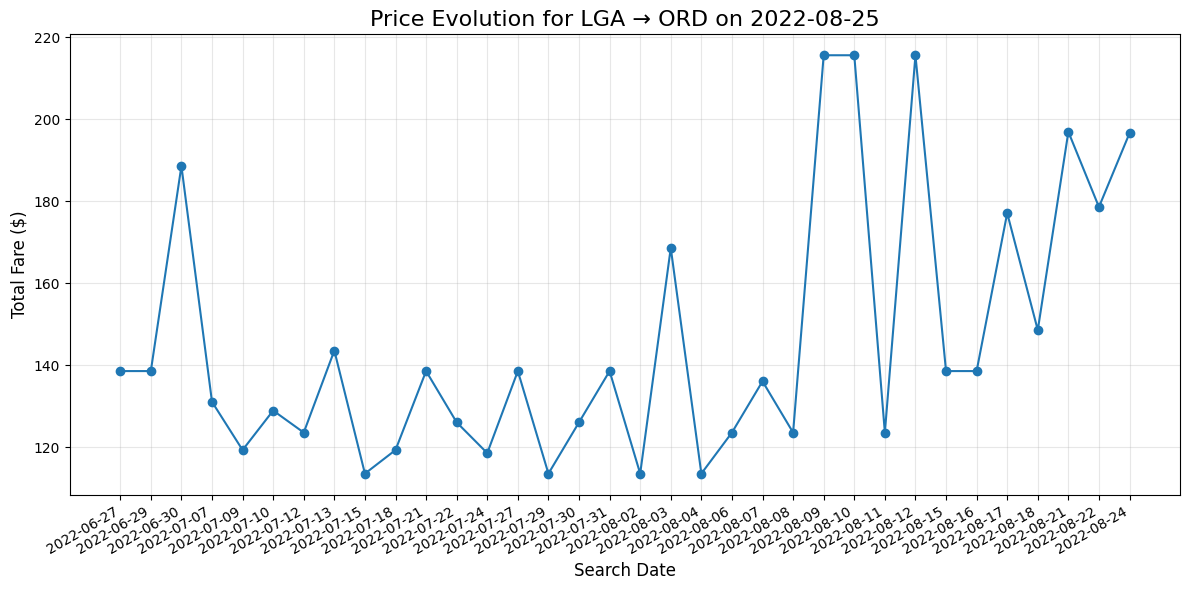

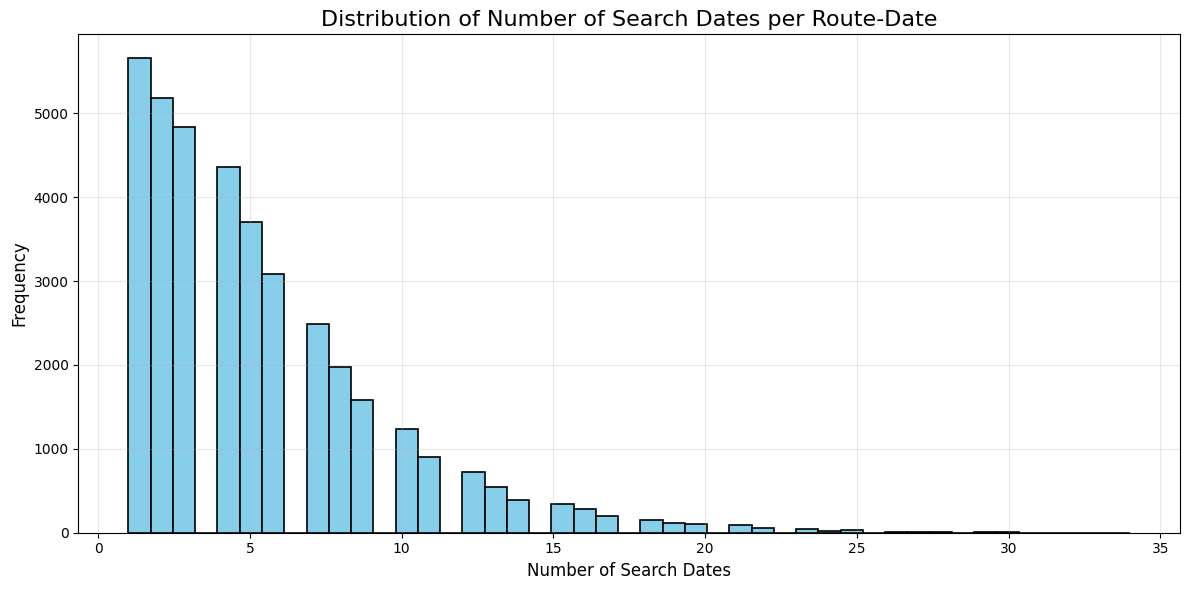

In [10]:
route_date_groups = group_routes_by_flight_date(df)

# Print summary statistics
print(f"Total number of unique routes and dates: {len(route_date_groups)}")

# Get a distribution of group sizes
group_sizes = [len(group) for group in route_date_groups.values()]

print(f"Average number of search dates per route-date: {np.mean(group_sizes):.2f}")
print(f"Median number of search dates per route-date: {np.median(group_sizes):.2f}")
print(f"Min number of search dates per route-date: {np.min(group_sizes)}")
print(f"Max number of search dates per route-date: {np.max(group_sizes)}")

# Create a sample visualization for the most frequently observed route-date
max_size = np.max(group_sizes)
for key, group in route_date_groups.items():
    if len(group) == max_size:
        start, dest, date = key
        print(f"\nMost frequently observed route-date: {start} → {dest} on {date}")

        # Plot price evolution for this route-date
        plt.figure(figsize=(12, 6))
        plt.plot(group["searchDate"], group["totalFare"], marker="o", linestyle="-")
        plt.title(f"Price Evolution for {start} → {dest} on {date}", fontsize=16)
        plt.xlabel("Search Date", fontsize=12)
        plt.ylabel("Total Fare ($)", fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.gcf().autofmt_xdate()
        plt.tight_layout()
        plt.show()
        break

# Plot distribution of number of search dates per route-date, each bar should be one route-date
plt.figure(figsize=(12, 6))
plt.hist(group_sizes, bins=45, color="skyblue", edgecolor="black", linewidth=1.2)
plt.title("Distribution of Number of Search Dates per Route-Date", fontsize=16)
plt.xlabel("Number of Search Dates", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
route_date_groups[("ATL", "BOS", "2022-08-21")]

,startingAirport,destinationAirport,flightDate,searchDate,baseFare,totalFare,seatsRemaining,fareBasisCode,elapsedDays,isBasicEconomy,isRefundable,isNonStop,totalTravelDistance,segmentsAirlineCode,segmentsEquipmentDescription,segmentsCabinCode,segmentsDepartureTime,segmentsArrivalTime,segmentsDuration
622,ATL,BOS,2022-08-21,2022-06-25,501.39,553.59,9.0,HA7OA0MQ,0,False,False,True,947.0,DL,Boeing 737-900,coach,2022-08-22 01:20:00,2022-08-22 03:58:00,0 days 02:38:00
623,ATL,BOS,2022-08-21,2022-06-30,236.28,268.60,9.0,UAVOA0MQ,0,False,False,True,947.0,DL,Airbus A321,coach,2022-08-21 14:25:00,2022-08-21 17:03:00,0 days 02:38:00
624,ATL,BOS,2022-08-21,2022-07-07,189.77,218.60,9.0,TAVOA0MQ,0,False,False,True,947.0,DL,Airbus A321,coach,2022-08-21 20:15:00,2022-08-21 22:59:00,0 days 02:44:00
625,ATL,BOS,2022-08-21,2022-07-10,189.77,218.60,9.0,TAVOA0MQ,0,False,False,True,947.0,DL,Airbus A321,coach,2022-08-21 20:15:00,2022-08-21 22:59:00,0 days 02:44:00
626,ATL,BOS,2022-08-21,2022-07-11,208.37,238.60,7.0,RC3AUEL1,0,False,False,True,947.0,B6,None,coach,2022-08-21 17:30:00,2022-08-21 20:11:00,0 days 02:41:00
627,ATL,BOS,2022-08-21,2022-07-22,189.77,218.60,9.0,TAVOA0MQ,0,False,False,True,947.0,DL,Airbus A321,coach,2022-08-21 23:55:00,2022-08-22 02:32:00,0 days 02:37:00
628,ATL,BOS,2022-08-21,2022-07-23,189.77,218.60,9.0,TAVOA0MQ,0,False,False,True,947.0,DL,Boeing 757-200,coach,2022-08-21 18:25:00,2022-08-21 21:00:00,0 days 02:35:00
629,ATL,BOS,2022-08-21,2022-07-26,208.37,238.60,2.0,LC3AUEY5,0,False,False,True,947.0,AA,None,coach,2022-08-21 17:30:00,2022-08-21 20:11:00,0 days 02:41:00
630,ATL,BOS,2022-08-21,2022-08-07,217.67,248.60,4.0,UAUQA0MQ,0,False,False,True,947.0,DL,Airbus A321,coach,2022-08-21 12:15:00,2022-08-21 14:52:00,0 days 02:37:00


Total number of unique routes and dates: 43343
Average number of search dates per route-date: 25.81
Median number of search dates per route-date: 26.00
Min number of search dates per route-date: 1
Max number of search dates per route-date: 60

Most frequently observed route-date: BOS → LGA on 2022-08-28


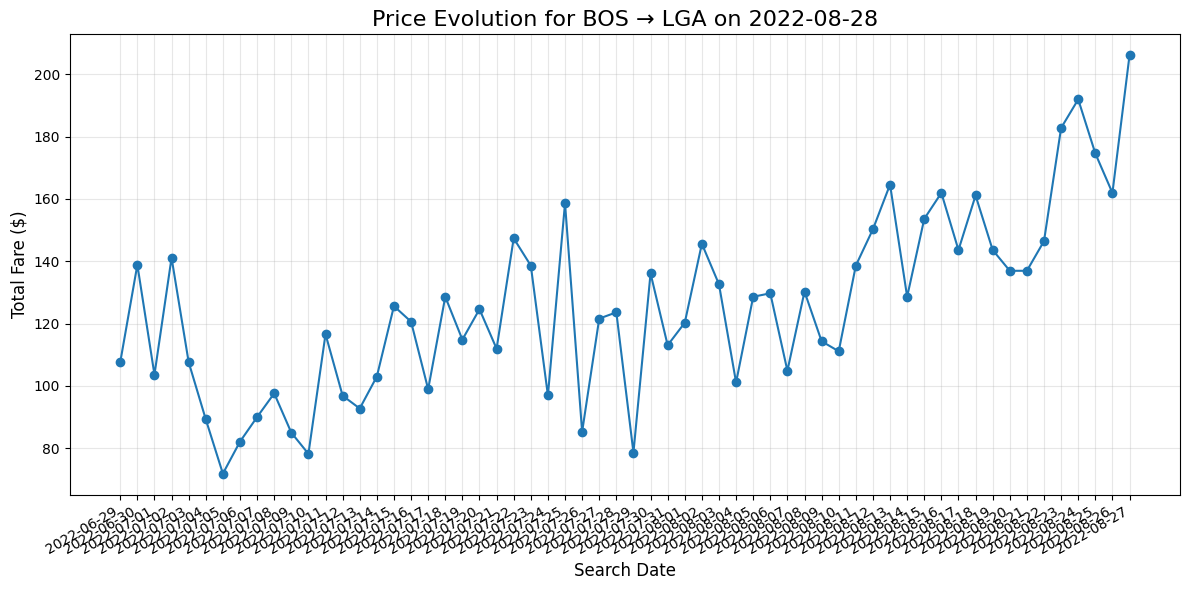

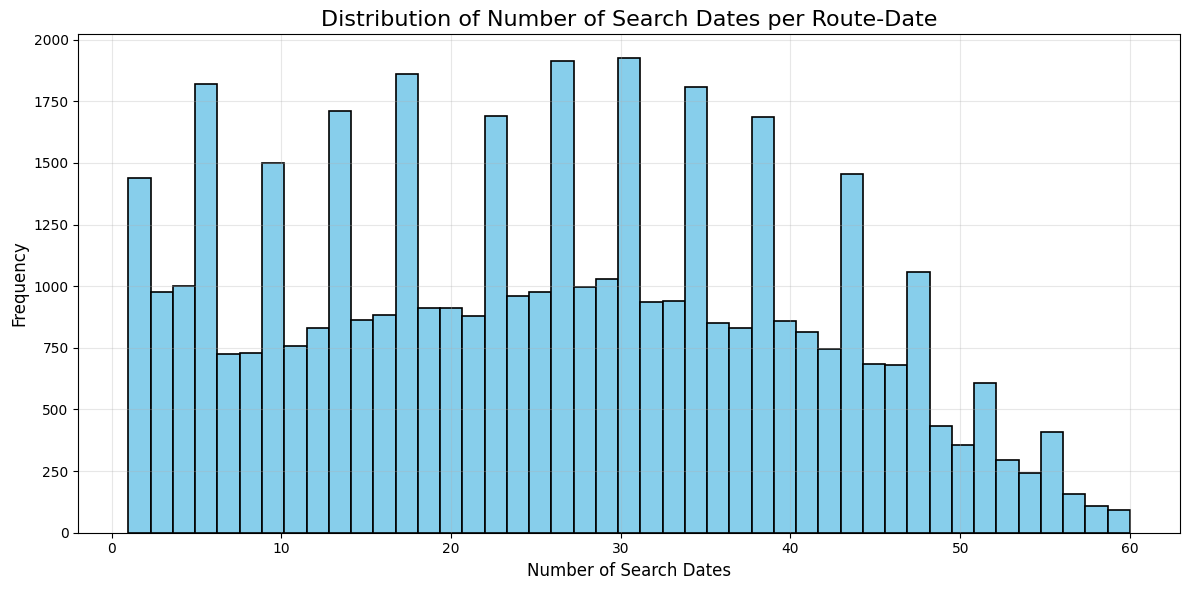

In [6]:
df_10p = pd.read_csv("data/filtered_data_10perc.csv")

# Transform segmentsDepartureTimeEpochSeconds and segmentsArrivalTimeEpochSeconds to datetime
df_10p["segmentsDepartureTime"] = pd.to_datetime(
    df_10p["segmentsDepartureTimeEpochSeconds"], unit="s"
)
df_10p["segmentsArrivalTime"] = pd.to_datetime(
    df_10p["segmentsArrivalTimeEpochSeconds"], unit="s"
)

# Transform segmentsDurationSeconds to HH:MM:SS
df_10p["segmentsDuration"] = pd.to_timedelta(
    df_10p["segmentsDurationInSeconds"], unit="s"
)

# Call the function
route_date_groups_10p = group_routes_by_flight_date(df_10p)

In [ ]:
def filter_dataframe_by_date_range(df):
    # Convert searchDate to datetime if it's not already
    if not pd.api.types.is_datetime64_dtype(df["searchDate"]):
        df["searchDate"] = pd.to_datetime(df["searchDate"])

    # Convert flightDate to datetime if it's not already
    if not pd.api.types.is_datetime64_dtype(df["flightDate"]):
        df["flightDate"] = pd.to_datetime(df["flightDate"])

    # Get the earliest and latest search dates
    earliest_search_date = df["searchDate"].min()
    latest_search_date = df["searchDate"].max()

    # Calculate the date thresholds
    min_flight_date = earliest_search_date + pd.Timedelta(days=30)
    max_flight_date = latest_search_date - pd.Timedelta(days=30)

    # Filter the dataframe
    filtered_df = df[
        (df["flightDate"] >= min_flight_date) & (df["flightDate"] <= max_flight_date)
    ]

    # Print the filtering information
    print(f"Original dataframe shape: {df.shape}")
    print(f"Filtered dataframe shape: {filtered_df.shape}")
    print(f"Earliest search date: {earliest_search_date}")
    print(f"Latest search date: {latest_search_date}")
    print(
        f"Min flight date threshold (earliest search date + 30 days): {min_flight_date}"
    )
    print(
        f"Max flight date threshold (latest search date + 30 days): {max_flight_date}"
    )
    print(
        f"Date range for flight dates: {filtered_df['flightDate'].min()} to {filtered_df['flightDate'].max()}"
    )

    return filtered_df


# Apply the filter to our dataframe
df_10p_filtered = filter_dataframe_by_date_range(df_10p)

In [ ]:
route_date_groups_10p_filtered = group_routes_by_flight_date(df_10p_filtered)